# AutoPhaseNN
#### Pytorch version (under development)

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"

import torch, torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchinfo import summary
from tqdm.notebook import tqdm 
import numpy as np
from numpy.fft import fftn, fftshift
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data.distributed import DistributedSampler
import matplotlib.pyplot as plt
import matplotlib

from data_loader import *
print(plt.style.available) 

plt.style.use('seaborn-v0_8-white') 
#matplotlib.rc('xtick', labelsize=20) 
#matplotlib.rc('ytick', labelsize=20)
matplotlib.rc('font',family='Times New Roman')
matplotlib.rcParams['font.size'] = 20
plt.viridis()
%matplotlib inline



['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


<Figure size 640x480 with 0 Axes>

## Define Contants
GPUs, Batch size, Training and Validation size, Shrink Wrap params, Epochs

In [2]:
import torch


EPOCHS = 60 #Full cycle is 12 epochs, good to end on a minimum

scale_I = 1 # normalize diff or not

MODEL_SAVE_PATH = './AutoPhase/SN/'
print(MODEL_SAVE_PATH)


# 打印 PyTorch 版本和 CUDA 支持状态
print("PyTorch 版本:", torch.__version__)
print("是否支持 CUDA:", torch.cuda.is_available())  # 关键：若为 False，说明是 CPU 版 PyTorch
print("CUDA 版本（若支持）:", torch.version.cuda)

NGPUS = torch.cuda.device_count()

BATCH_SIZE = 16 
LR = NGPUS * 1e-4
print("GPUs:", NGPUS, "Batch size:", BATCH_SIZE, "Learning rate:", LR)

N_TRAIN = 20
N_VALID = int(0.1*N_TRAIN)
TRAIN_ratio = 0.9

INIT_SW = 0.07
FINAL_SW = 0.1 #Anything >0.07 seems to break it
CONST_EPOCHS = 0 #How many epochs to not increase SW

SW_INCREMENT = (FINAL_SW-INIT_SW)/(EPOCHS-1-CONST_EPOCHS)
print("SW Thresh increment", SW_INCREMENT)

print ("PyTorch version", torch.__version__)


./AutoPhase/SN/
PyTorch 版本: 2.8.0+cu129
是否支持 CUDA: True
CUDA 版本（若支持）: 12.9
GPUs: 1 Batch size: 16 Learning rate: 0.0001
SW Thresh increment 0.0005084745762711864
PyTorch version 2.8.0+cu129


### Plotting Helper

## Load and check data, then prepare as tensors

In [4]:
# # data loader
data_path = 'D:/code/PYTHON\AutoPhaseNN-main/TF2/CDI_simulation_upsamp_noise/'

dataname_list = os.path.join(data_path, '3D_upsamp.txt')
filelist = []

with open(dataname_list, 'r') as f:
    txtfile = f.readlines()
for i in range(len(txtfile)):
    tmp = str(txtfile[i]).split('/')[-1]
    tmp = tmp.split('\n')[0]

    filelist.append(tmp)
f.close()
print('number of available file:%d' % len(filelist))

# give training data size and filelist
# train_file_indxs = np.random.randint(len(filelist), size=N_TRAIN).astype('int')
# train_filelist = [filelist[idx] for idx in train_file_indxs]
train_filelist = filelist[:N_TRAIN]
print('number of training:%d' % len(train_filelist))


number of available file:3290
number of training:20


In [5]:
# load training data and validation data
train_dataset = Dataset(
    train_filelist, data_path, load_all=False, ratio=TRAIN_ratio, dataset='train',scale_I=scale_I)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NGPUS*8)
# train_sampler = DistributedSampler(
#     train_dataset, num_replicas=NGPUS, rank=rank, shuffle=True)
# train_loader = DataLoader(
#     train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, shuffle=False, num_workers=NGPUS*8)


validation_dataset = Dataset(
    train_filelist, data_path, load_all=False, ratio=TRAIN_ratio, dataset='validation',scale_I=scale_I)
validation_loader = DataLoader(
    validation_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NGPUS*64)
# validation_sampler = DistributedSampler(
#     validation_dataset, num_replicas=NGPUS, rank=rank, shuffle=True)
# validation_loader = DataLoader(
#     validation_dataset, batch_size=BATCH_SIZE, sampler=validation_sampler, shuffle=False, num_workers=NGPUS*8)

c:\Users\30810\.conda\envs\pt-AutoPhaseNN\lib\site-packages\torch\utils\data\dataloader.py:627: UserWarning: This DataLoader will create 64 worker processes in total. Our suggested max number of worker in current system is 12 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


### Check the model works

In [6]:
from AutoPhaseNN_model_relu import Network
import argparse


parser = argparse.ArgumentParser()
parser.add_argument('--shape', type=int, default=64)  # 输入维度64x64x64
parser.add_argument('--T', type=float, default=0.1)       # 时间维度（假设）
parser.add_argument('--nconv', type=int, default=32)   # 初始卷积数（对应TF的32）
parser.add_argument('--use_down_stride', type=bool, default=False)  # 按你的实际配置
parser.add_argument('--use_up_stride', type=bool, default=False)    # 按你的实际配置
parser.add_argument('--n_blocks', type=int, default=4)  # Encoder 4个block（对应TF 4个MaxPool）
parser.add_argument('--unsupervise', type=bool, default=True) 
parser.add_argument('--scale_I', type=int, default=1) 
argv = parser.parse_args([])  # 空列表表示不读取命令行参数

model = Network(argv)
#model = recon_model()
for ft_images,amps,phs in train_loader:
    print("batch size:", ft_images.shape, amps.shape, phs.shape)
    #outs = model(ft_images)
    #print(*[o.shape for o in outs])
    #print(*[o.dtype for o in outs])
    y, complex_x, amp, ph, _ = model(ft_images)
    print(y.shape, complex_x.shape, amp.shape, ph.shape)
    print(y.dtype, complex_x.dtype, amp.dtype, ph.dtype)
    break

batch size: torch.Size([16, 1, 64, 64, 64]) torch.Size([16, 1, 64, 64, 64]) torch.Size([16, 1, 64, 64, 64])
torch.Size([16, 1, 64, 64, 64]) torch.Size([16, 1, 64, 64, 64]) torch.Size([16, 1, 64, 64, 64]) torch.Size([16, 1, 64, 64, 64])
torch.float32 torch.complex64 torch.float32 torch.float32


In [24]:
h = w = t = 64
summary(model, (1, 1, h, w, t), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
Network                                  [1, 1, 64, 64, 64]        --
├─Sequential: 1-1                        [1, 512, 4, 4, 4]         --
│    └─Conv3d: 2-1                       [1, 32, 64, 64, 64]       896
│    └─ReLU: 2-2                         [1, 32, 64, 64, 64]       --
│    └─BatchNorm3d: 2-3                  [1, 32, 64, 64, 64]       64
│    └─Conv3d: 2-4                       [1, 32, 64, 64, 64]       27,680
│    └─ReLU: 2-5                         [1, 32, 64, 64, 64]       --
│    └─BatchNorm3d: 2-6                  [1, 32, 64, 64, 64]       64
│    └─MaxPool3d: 2-7                    [1, 32, 32, 32, 32]       --
│    └─Conv3d: 2-8                       [1, 64, 32, 32, 32]       55,360
│    └─ReLU: 2-9                         [1, 64, 32, 32, 32]       --
│    └─BatchNorm3d: 2-10                 [1, 64, 32, 32, 32]       128
│    └─Conv3d: 2-11                      [1, 64, 32, 32, 32]       110,656


### Move model to appropriate device

In [7]:
model = Network(argv)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if NGPUS > 1:
    print("Let's use", torch.cuda.device_count(), "GPUs!")
    # dim = 0 [30, xxx] -> [10, ...], [10, ...], [10, ...] on 3 GPUs
    model = nn.DataParallel(model) #Default all devices

model = model.to(device)

n_filt_in: 1
n_filt_out: 32
use_down_stride False
n_filt_in: 32
n_filt_out: 64
use_down_stride False
n_filt_in: 64
n_filt_out: 128
use_down_stride False
n_filt_in: 128
n_filt_out: 256
use_down_stride False
n_filt_in: 256
n_filt_out: 512
use_down_stride True


## Setup optimizer and cyclicLR

In [8]:
#Optimizer details
iterations_per_epoch = np.floor((N_TRAIN*TRAIN_ratio)/BATCH_SIZE)+1 #Final batch will be less than batch size
step_size = 6*iterations_per_epoch #Paper recommends 2-10 number of iterations, step_size is half cycle
print("LR step size is:", step_size, "which is every %d epochs" %(step_size/iterations_per_epoch))

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr = LR)
scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=LR, 
                                              max_lr=LR*5, step_size_up=step_size,
                                              cycle_momentum=False, mode='triangular2')

LR step size is: 12.0 which is every 6 epochs


## Training and Validation Loop

In [ ]:
#Function to update saved model if validation loss is minimum
def update_saved_model(model, path):
    if not os.path.isdir(path):
        os.mkdir(path)
    for f in os.listdir(path):
        os.remove(os.path.join(path, f))
    if NGPUS > 1:
        torch.save(model.module.state_dict(),path+'best_model.pth') #Have to save the underlying model else will always need 4 GPUs
    else:
        torch.save(model.state_dict(),path+'best_model.pth')

In [ ]:
def train(trainloader,metrics):
    loss_ft = 0.0
    loss_amp = 0.0
    loss_ph = 0.0
    
    for i, (ft_images,amps,phs) in tqdm(enumerate(trainloader)):
        ft_images = ft_images.to(device) #Move everything to device
        amps = amps.to(device)
        phs = phs.to(device)

        y, _, pred_amps, pred_phs, support = model(ft_images) #Forward pass
        
        #Compute losses
        loss_f = criterion(y, ft_images)
        loss_a = criterion(pred_amps,amps) #Monitor amplitude loss
        loss_p = criterion(pred_phs*support,phs) #Monitor phase loss but only within support (which may not be same as true amp)
        loss = loss_f #Use only FT loss for gradients
        #loss = loss_a + loss_p + loss_f

        #Zero current grads and do backprop
        optimizer.zero_grad() 
        loss.backward()
        optimizer.step()

        loss_ft += loss_f.detach().item()
        loss_amp += loss_a.detach().item()
        loss_ph += loss_p.detach().item()
        #loss_ft = 0

        #Update the LR according to the schedule -- CyclicLR updates each batch
        scheduler.step() 
        metrics['lrs'].append(scheduler.get_last_lr())
        
        
    #Divide cumulative loss by number of batches-- sli inaccurate because last batch is different size
    metrics['losses'].append([loss_ft/i,loss_amp/i,loss_ph/i]) 
    

def validate(validloader,metrics):
    val_loss_ft = 0.0
    val_loss_amp = 0.0
    val_loss_ph = 0.0
    for j, (ft_images,amps,phs) in enumerate(validloader):
        ft_images = ft_images.to(device)
        amps = amps.to(device)
        phs = phs.to(device)
        y, _, pred_amps, pred_phs, support = model(ft_images) #Forward pass
        #pred_amps, pred_phs, support = model(ft_images) #Forward pass
    
        val_loss_f = criterion(y, ft_images)
        val_loss_a = criterion(pred_amps,amps) 
        val_loss_p = criterion(pred_phs*support,phs) 
    
        val_loss_ft += val_loss_f.detach().item()
        val_loss_amp += val_loss_a.detach().item()
        val_loss_ph += val_loss_p.detach().item()  
        
    metrics['val_losses'].append([val_loss_ft/j,val_loss_amp/j,val_loss_ph/j])
    
  #Update saved model if val loss is lower
    if(val_loss_ft/j<metrics['best_val_loss']):
        print("Saving improved model after Val Loss improved from %.5f to %.5f" %(metrics['best_val_loss'],val_loss_ft/j))
        metrics['best_val_loss'] = val_loss_ft/j
        update_saved_model(model, MODEL_SAVE_PATH)

In [ ]:
metrics = {'losses':[],'val_losses':[], 'lrs':[], 'best_val_loss' : np.inf}

for epoch in tqdm(range(EPOCHS)):
    
    #Set model to train mode
    model.train() 

    #Training loop
    train(train_loader,metrics)

    #Switch model to eval mode
    model.eval()

#     Validation loop
    validate(validation_loader,metrics)
    l = metrics['losses'][-1]
    lv =  metrics['val_losses'][-1]

    print(f'Epoch: {epoch} | FT  | Train Loss: {l[0]:.5f} | Val Loss: {lv[0]:.5f}')
    print(f'Epoch: {epoch} | Amp | Train Loss: {l[1]:.4f} | Val Loss: {lv[1]:.5f}')
    print(f'Epoch: {epoch} | Ph  | Train Loss: {l[2]:.3f} | Val Loss: {lv[2]:.5f}')
    if NGPUS>1:
        print(f'Epoch: {epoch} | SW Thresh: {model.module.sw_thresh:.4f}')
    else:
        print(f'Epoch: {epoch} | SW Thresh: {model.sw_thresh:.4f}')
           
    print(f'Epoch: {epoch} | Ending LR: {metrics["lrs"][-1][0]:.6f}')

    if(epoch>=(CONST_EPOCHS-1)): #Keep SW thresh =0 i.e fixed half box support for first N epochs
        if NGPUS>1:
            model.module.sw_thresh+=SW_INCREMENT #Update shrink-wrap threshold every epoch
        else:
            model.sw_thresh+=SW_INCREMENT #Update shrink-wrap threshold every epoch

In [ ]:
batches = np.linspace(0,len(metrics['lrs']),len(metrics['lrs'])+1)
epoch_list = batches/iterations_per_epoch

plt.plot(epoch_list[1:],metrics['lrs'], 'C3-')
plt.grid()
plt.ylabel("Learning rate")
plt.xlabel("Epoch")

In [ ]:
losses_arr = np.array(metrics['losses'])
val_losses_arr = np.array(metrics['val_losses'])
losses_arr.shape
fig, ax = plt.subplots(3,sharex=True, figsize=(15, 8))
ax[0].plot(losses_arr[:,0], 'C3o-', label = "Train FT loss")
ax[0].plot(val_losses_arr[:,0], 'C0o-', label = "Val FT loss")
ax[0].set(ylabel='Loss')
ax[0].grid()
ax[0].legend(loc='center right', bbox_to_anchor=(1.5, 0.5))
ax[1].plot(losses_arr[:,1], 'C3o-', label = "Train Amp loss")
ax[1].plot(val_losses_arr[:,1], 'C0o-', label = "Val Amp loss")
ax[1].set(ylabel='Loss')
ax[1].grid()
ax[1].legend(loc='center right', bbox_to_anchor=(1.5, 0.5))
ax[2].plot(losses_arr[:,2], 'C3o-', label = "Train Ph loss")
ax[2].plot(val_losses_arr[:,2], 'C0o-', label = "Val Ph loss")
ax[2].set(ylabel='Loss')
ax[2].grid()
ax[2].legend(loc='center right', bbox_to_anchor=(1.5, 0.5))

plt.tight_layout()
plt.xlabel("Epochs")


In [10]:
# load test data
# give test data filelist
test_filelist = filelist[0:100]
print('number of test data:%d' % len(test_filelist))

# load test data 
test_dataset = Dataset(
    test_filelist, data_path, load_all=False, ratio=TRAIN_ratio, dataset='test',scale_I=scale_I,shuffle=False)
test_loader = DataLoader(
    test_dataset, batch_size=16, shuffle=False, num_workers=NGPUS)
# test_sampler = DistributedSampler(
#     test_dataset, num_replicas=1, rank=rank, shuffle=False)
# test_loader = DataLoader(
#     test_dataset, batch_size=16, sampler=test_sampler, shuffle=False, **kwargs)

number of test data:100


# load saved model

In [9]:
model_path = "../torch_transferred_weights_final.pth"
# 2. 加载参数文件，指定 map_location 解决 CUDA 不可用问题
# 方案1：强制映射到 CPU（你的环境适用，因为 torch.cuda.is_available() 是 False）
params = torch.load(model_path, map_location=torch.device("cpu"))

# 方案2：自动映射到当前可用设备（更通用，有GPU用GPU，无GPU用CPU）
#params = torch.load(model_path, map_location=torch.device("cuda" if torch.cuda.is_available() else "cpu"))

# 3. 将参数注入模型
model.load_state_dict(params)

# 4. （可选）设置模型为评估模式（若用于推理/测试，非训练）
model.eval()

Network(
  (encoder): Sequential(
    (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): ReLU()
    (2): BatchNorm3d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): ReLU()
    (5): BatchNorm3d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (6): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
    (7): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (8): ReLU()
    (9): BatchNorm3d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (10): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (11): ReLU()
    (12): BatchNorm3d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (13): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
   

In [10]:
import torch
import torch.nn as nn
import numpy as np

# ====================== 1. 加载TF环境保存的输入，转PyTorch格式 ======================
tf_input = np.load("../TF2/test_input_tf.npy")  # 直接用TF保存的输入，保证完全一致
# TF输入：NHWDC → PyTorch输入：NCDHW
pt_input = torch.tensor(tf_input).permute(0, 4, 1, 2, 3).contiguous().to(torch.float32)

# ====================== 2. 加载PyTorch模型（迁移好权重的） ======================
torch_model = model


# ====================== 3. 逐层输出 + 单文件保存（和TF格式对齐） ======================
pt_layer_info = []
pt_outputs = []  # 存每层输出
pt_layer_names = []  # 存每层名称
pt_layer_types = []  # 存每层类型

# 修复钩子函数：处理output是tuple的情况（核心改这里！）
def hook_fn(module, input, output, name, type_str):
    # 关键：如果output是tuple，取第一个元素（大部分模型的多输出层只取主输出）
    if isinstance(output, tuple):
        output = output[0]  # 改成这一行，解决tuple报错
    # 输出转numpy，格式和TF对齐（NHWDC）
    out_np = output.detach().cpu().numpy()
    out_np = out_np.transpose(0, 2, 3, 4, 1)  # NCDHW → NHWDC
    pt_outputs.append(out_np)
    pt_layer_names.append(name)
    pt_layer_types.append(type_str)

# 遍历层，注册钩子（跳过Input/Sequential，和TF的valid_layers对齐）
hook_handles = []
for name, module in torch_model.named_modules():
    if (("input" not in name.lower()) and 
        not isinstance(module, nn.Sequential) and 
        not isinstance(module, torch_model.__class__)):  # 跳过模型本身
        type_str = module.__class__.__name__
        handle = module.register_forward_hook(
            lambda m, i, o, n=name, t=type_str: hook_fn(m, i, o, n, t)
        )
        hook_handles.append(handle)

# 前向计算
with torch.no_grad():
    torch_model(pt_input)

# 按索引整理信息（和TF格式完全一致）
for idx, (name, type_str, out) in enumerate(zip(pt_layer_names, pt_layer_types, pt_outputs)):
    pt_layer_info.append({
        "index": idx,          # 层索引（和TF按顺序对比）
        "layer_name": name,    # PyTorch层名（人工核对用）
        "layer_type": type_str,  # 层类型（辅助核对）
        "output": out          # 层输出结果
    })

# 保存为单个文件（只有这1个文件！没有每层存！）
np.save("pt_all_layers.npy", pt_layer_info, allow_pickle=True)
print(f"✅ PyTorch层信息已保存到单个文件：pt_all_layers.npy")
print(f"✅ PyTorch有效层数：{len(pt_layer_info)}")
# 打印PyTorch层索引+名称（方便后续核对）
for info in pt_layer_info:
    print(f"PT索引{info['index']}：{info['layer_name']}（{info['layer_type']}）")

# 移除钩子（避免内存泄漏）
for handle in hook_handles:
    handle.remove()      

NotImplementedError: Could not run 'aten::slow_conv3d_forward' with arguments from the 'CUDA' backend. This could be because the operator doesn't exist for this backend, or was omitted during the selective/custom build process (if using custom build). If you are a Facebook employee using PyTorch on mobile, please visit https://fburl.com/ptmfixes for possible resolutions. 'aten::slow_conv3d_forward' is only available for these backends: [CPU, Meta, BackendSelect, Python, FuncTorchDynamicLayerBackMode, Functionalize, Named, Conjugate, Negative, ZeroTensor, ADInplaceOrView, AutogradOther, AutogradCPU, AutogradCUDA, AutogradHIP, AutogradXLA, AutogradMPS, AutogradIPU, AutogradXPU, AutogradHPU, AutogradVE, AutogradLazy, AutogradMTIA, AutogradMAIA, AutogradPrivateUse1, AutogradPrivateUse2, AutogradPrivateUse3, AutogradMeta, AutogradNestedTensor, Tracer, AutocastCPU, AutocastMTIA, AutocastMAIA, AutocastXPU, AutocastMPS, AutocastCUDA, FuncTorchBatched, BatchedNestedTensor, FuncTorchVmapMode, Ba

In [11]:

# 1. 获取目标层（decoder1.22）
layer = model.decoder1[22]  # 根据模型结构调整索引或名称

# 2. 打印层结构
print("=== 层结构概览 ===")
print(layer)

# 3. 打印核心配置（卷积层参数）
if isinstance(layer, nn.Conv3d):
    print("\n=== 卷积层配置 ===")
    print(f"name: {layer}")
    print(f"filters / out_channels: {layer.out_channels}")
    print(f"kernel_size: {layer.kernel_size}")
    print(f"strides / stride: {layer.stride}")
    print(f"padding: {layer.padding}")
    print(f"dilation: {layer.dilation}")
    print(f"groups: {layer.groups}")
    print(f"use_bias: {layer.bias is not None}")
    print(f"activation: None (PyTorch 卷积层不内置激活函数)")

    # 4. 获取权重和偏置
    kernel_weights = layer.weight.data.cpu().numpy()
    bias_weights = layer.bias.data.cpu().numpy() if layer.bias is not None else None

    # 输出卷积核权重信息
    print("\n1. 卷积核权重（kernel_weights）")
    print(f"   - 形状: {kernel_weights.shape}")  # (out_channels, in_channels, D, H, W)
    print(f"   - 数据类型: {kernel_weights.dtype}")
    print(f"   - 部分数值（取前1个输出通道、前2个输入通道、前1个深度、高、宽）：")
    sample_kernel = kernel_weights[:1, :2, :1, :1, :1]
    print(np.round(sample_kernel, 4))

    # 输出偏置
    if bias_weights is not None:
        print("\n2. 偏置项（bias_weights）")
        print(f"   - 形状: {bias_weights.shape}")
        print(f"   - 数据类型: {bias_weights.dtype}")
        print(f"   - 部分数值（取前8个输出通道对应的偏置）：")
        sample_bias = bias_weights[:8]
        print(np.round(sample_bias, 4))
    else:
        print("\n2. 偏置项（bias_weights）：该层 use_bias=False，无偏置可训练参数")
else:
    print("目标层不是 Conv3d，请检查索引或层类型！")


=== 层结构概览 ===
Conv3d(64, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))

=== 卷积层配置 ===
name: Conv3d(64, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
filters / out_channels: 32
kernel_size: (3, 3, 3)
strides / stride: (1, 1, 1)
padding: (1, 1, 1)
dilation: (1, 1, 1)
groups: 1
use_bias: True
activation: None (PyTorch 卷积层不内置激活函数)

1. 卷积核权重（kernel_weights）
   - 形状: (32, 64, 3, 3, 3)
   - 数据类型: float32
   - 部分数值（取前1个输出通道、前2个输入通道、前1个深度、高、宽）：
[[[[[-0.0276]]]


  [[[ 0.0242]]]]]

2. 偏置项（bias_weights）
   - 形状: (32,)
   - 数据类型: float32
   - 部分数值（取前8个输出通道对应的偏置）：
[-0.0215  0.0624  0.07   -0.0995  0.0006  0.2883  0.0417 -0.0829]


In [12]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader

# ====================== 1. 加载数据：指定第7个样本 (修改部分) ======================
# 初始化 Dataset
test_dataset = Dataset(
    test_filelist, 
    data_path, 
    load_all=False, 
    ratio=TRAIN_ratio, 
    dataset='test',
    scale_I=scale_I,
    shuffle=False
)

# 锁定第7个样本 (索引为6)
target_idx = 6

# 1. 输出样本名称
sample_name = test_filelist[target_idx]
print(f"👉 当前使用的样本名称: {sample_name}")

# 2. 获取数据 (处理Dataset可能返回元组的情况)
sample_data = test_dataset[target_idx]
if isinstance(sample_data, (tuple, list)):
    img_tensor = sample_data[0] # 通常第一个元素是图像
else:
    img_tensor = sample_data

# 3. 构造模型输入
# Dataset返回通常是 (C, D, H, W)，需要增加 Batch 维度 -> (1, C, D, H, W)
if isinstance(img_tensor, np.ndarray):
    pt_input = torch.tensor(img_tensor)
else:
    pt_input = img_tensor.clone()

pt_input = pt_input.unsqueeze(0).to(torch.float32)

# 确保输入在正确的设备上 (GPU/CPU)
device = next(model.parameters()).device
pt_input = pt_input.to(device)

print(f"👉 PyTorch输入形状: {pt_input.shape}") # 预期应为 (1, C, D, H, W)

# ====================== 2. 加载PyTorch模型（保持不变） ======================
torch_model = model
torch_model.eval() # 显式开启评估模式

# ====================== 3. 逐层输出 + 单文件保存（保持不变） ======================
pt_layer_info = []
pt_outputs = []   # 存每层输出
pt_layer_names = []   # 存每层名称
pt_layer_types = []   # 存每层类型

# 修复钩子函数：处理output是tuple的情况
def hook_fn(module, input, output, name, type_str):
    # 关键：如果output是tuple，取第一个元素
    if isinstance(output, tuple):
        output = output[0]
    # 输出转numpy，格式和TF对齐（NHWDC）
    out_np = output.detach().cpu().numpy()
    # 注意：这里假设模型输出仍是5维 (N, C, D, H, W) 才进行转换
    # 如果遇到全连接层等非5维输出，transpose可能会报错，这里保留原逻辑
    if len(out_np.shape) == 5:
        out_np = out_np.transpose(0, 2, 3, 4, 1)  # NCDHW → NHWDC
    
    pt_outputs.append(out_np)
    pt_layer_names.append(name)
    pt_layer_types.append(type_str)

# 遍历层，注册钩子
hook_handles = []
for name, module in torch_model.named_modules():
    if (("input" not in name.lower()) and 
        not isinstance(module, nn.Sequential) and 
        not isinstance(module, torch_model.__class__)):  # 跳过模型本身
        type_str = module.__class__.__name__
        handle = module.register_forward_hook(
            lambda m, i, o, n=name, t=type_str: hook_fn(m, i, o, n, t)
        )
        hook_handles.append(handle)

# 前向计算
with torch.no_grad():
    torch_model(pt_input)

# 按索引整理信息（和TF格式完全一致）
for idx, (name, type_str, out) in enumerate(zip(pt_layer_names, pt_layer_types, pt_outputs)):
    pt_layer_info.append({
        "index": idx,          # 层索引
        "layer_name": name,    # PyTorch层名
        "layer_type": type_str,  # 层类型
        "output": out          # 层输出结果
    })

# 保存为单个文件
np.save("pt_all_layers.npy", pt_layer_info, allow_pickle=True)
print(f"✅ PyTorch层信息已保存到单个文件：pt_all_layers.npy")
print(f"✅ PyTorch有效层数：{len(pt_layer_info)}")
# 打印PyTorch层索引+名称
for info in pt_layer_info:
    print(f"PT索引{info['index']}：{info['layer_name']}（{info['layer_type']}）")

# 移除钩子
for handle in hook_handles:
    handle.remove()

NameError: name 'test_filelist' is not defined

In [15]:
import torch
import torch.nn as nn
import numpy as np

# ====================== 1. 加载TF环境保存的输入，转PyTorch格式 ======================
tf_input = np.load("../TF2/test_input_tf.npy")  # 直接用TF保存的输入，保证完全一致
# TF输入：NHWDC → PyTorch输入：NCDHW
pt_input = torch.tensor(tf_input).permute(0, 4, 1, 2, 3).contiguous().to(torch.float32)

# ====================== 2. 加载PyTorch模型（迁移好权重的） ======================
torch_model = model

# ====================== 3. 逐层输出 + 单文件保存（和TF格式对齐） ======================
pt_layer_info = []
pt_outputs = []  # 存每层输出
pt_layer_names = []  # 存每层名称
pt_layer_types = []  # 存每层类型

# 修复钩子函数：处理output是tuple的情况（核心改这里！）
def hook_fn(module, input, output, name, type_str):
    # 关键：如果output是tuple，取第一个元素（大部分模型的多输出层只取主输出）
    if isinstance(output, tuple):
        output = output[0]  # 改成这一行，解决tuple报错
    # 输出转numpy，格式和TF对齐（NHWDC）
    out_np = output.detach().cpu().numpy()
    out_np = out_np.transpose(0, 2, 3, 4, 1)  # NCDHW → NHWDC
    pt_outputs.append(out_np)
    pt_layer_names.append(name)
    pt_layer_types.append(type_str)

# 遍历层，注册钩子（跳过Input/Sequential，和TF的valid_layers对齐）
hook_handles = []
for name, module in torch_model.named_modules():
    if (("input" not in name.lower()) and 
        not isinstance(module, nn.Sequential) and 
        not isinstance(module, torch_model.__class__)):  # 跳过模型本身
        type_str = module.__class__.__name__
        handle = module.register_forward_hook(
            lambda m, i, o, n=name, t=type_str: hook_fn(m, i, o, n, t)
        )
        hook_handles.append(handle)

# 前向计算
with torch.no_grad():
    torch_model(pt_input)

# 按索引整理信息（和TF格式完全一致）
for idx, (name, type_str, out) in enumerate(zip(pt_layer_names, pt_layer_types, pt_outputs)):
    pt_layer_info.append({
        "index": idx,          # 层索引（和TF按顺序对比）
        "layer_name": name,    # PyTorch层名（人工核对用）
        "layer_type": type_str,  # 层类型（辅助核对）
        "output": out          # 层输出结果
    })

# 保存为单个文件（只有这1个文件！没有每层存！）
np.save("pt_all_layers.npy", pt_layer_info, allow_pickle=True)
print(f"✅ PyTorch层信息已保存到单个文件：pt_all_layers.npy")
print(f"✅ PyTorch有效层数：{len(pt_layer_info)}")
# 打印PyTorch层索引+名称（方便后续核对）
for info in pt_layer_info:
    print(f"PT索引{info['index']}：{info['layer_name']}（{info['layer_type']}）")

# 移除钩子（避免内存泄漏）
for handle in hook_handles:
    handle.remove()

✅ PyTorch层信息已保存到单个文件：pt_all_layers.npy
✅ PyTorch有效层数：99
PT索引0：encoder.0（Conv3d）
PT索引1：encoder.1（ReLU）
PT索引2：encoder.2（BatchNorm3d）
PT索引3：encoder.3（Conv3d）
PT索引4：encoder.4（ReLU）
PT索引5：encoder.5（BatchNorm3d）
PT索引6：encoder.6（MaxPool3d）
PT索引7：encoder.7（Conv3d）
PT索引8：encoder.8（ReLU）
PT索引9：encoder.9（BatchNorm3d）
PT索引10：encoder.10（Conv3d）
PT索引11：encoder.11（ReLU）
PT索引12：encoder.12（BatchNorm3d）
PT索引13：encoder.13（MaxPool3d）
PT索引14：encoder.14（Conv3d）
PT索引15：encoder.15（ReLU）
PT索引16：encoder.16（BatchNorm3d）
PT索引17：encoder.17（Conv3d）
PT索引18：encoder.18（ReLU）
PT索引19：encoder.19（BatchNorm3d）
PT索引20：encoder.20（MaxPool3d）
PT索引21：encoder.21（Conv3d）
PT索引22：encoder.22（ReLU）
PT索引23：encoder.23（BatchNorm3d）
PT索引24：encoder.24（Conv3d）
PT索引25：encoder.25（ReLU）
PT索引26：encoder.26（BatchNorm3d）
PT索引27：encoder.27（MaxPool3d）
PT索引28：encoder.28（Conv3d）
PT索引29：encoder.29（ReLU）
PT索引30：encoder.30（BatchNorm3d）
PT索引31：encoder.31（Conv3d）
PT索引32：encoder.32（ReLU）
PT索引33：encoder.33（BatchNorm3d）
PT索引34：decoder1.0（Upsample）
PT索引35：dec

In [16]:
import torch
import torch.nn as nn

def loss_log(Y_true, Y_pred):
    # 使用 log10(x + 1)
    pred = torch.log10(Y_pred + 1.0)
    true = torch.log10(Y_true + 1.0)

    top = torch.sum(torch.pow(pred - true, 2))
    bottom = torch.sum(torch.pow(true, 2))
    
    loss_value = top / (bottom + 1e-8) # 防止除零
    return loss_value

def loss_sq(Y_true, Y_pred):
    # 针对 3D 数据 (Batch, Channel, H, W, D)，对空间维度求和
    # 如果 Channel 只有 1，dim=(1,2,3,4)；如果输入是 (B, H, W, D)，dim=(1,2,3)
    dims = tuple(range(1, Y_true.ndim)) 
    
    top = torch.sum(torch.pow(Y_pred - Y_true, 2), dim=dims, keepdim=True)
    bottom = torch.sum(torch.pow(Y_true, 2), dim=dims, keepdim=True)

    loss_value = torch.sum(top / (bottom + 1e-8))
    return loss_value

def loss_mae(Y_true, Y_pred):
    dims = tuple(range(1, Y_true.ndim))
    
    top = torch.sum(torch.abs(Y_pred - Y_true), dim=dims, keepdim=True)
    bottom = torch.sum(torch.abs(Y_true), dim=dims, keepdim=True)
    
    loss_value = torch.sum(top / (bottom + 1e-8))
    return loss_value

def loss_paper(Y_true, Y_pred):
    # Y_true: 测量衍射强度 (Im)，Y_pred: 估计衍射强度 (Ie)
    # 根据论文公式：Sum|sqrt(Ie) - sqrt(Im)| / N^3 [cite: 192, 194]
    sqrt_true = torch.sqrt(torch.clamp(Y_true, min=0.0))
    sqrt_pred = torch.sqrt(torch.clamp(Y_pred, min=0.0))
    
    abs_error = torch.abs(sqrt_pred - sqrt_true)
    total_error = torch.sum(abs_error)
    
    # N^3 = 64x64x64 = 262144 [cite: 194]
    loss_value = total_error / 262144.0
    return loss_value

def loss_pcc(Y_true, Y_pred):
    dims = tuple(range(1, Y_true.ndim))
    
    # 计算均值
    pred_mean = torch.mean(Y_pred, dim=dims, keepdim=True)
    true_mean = torch.mean(Y_true, dim=dims, keepdim=True)
    
    # 中心化
    pred_centered = Y_pred - pred_mean
    true_centered = Y_true - true_mean
    
    top = torch.sum(pred_centered * true_centered, dim=dims, keepdim=True)
    
    pred_var_sum = torch.sum(torch.pow(pred_centered, 2), dim=dims, keepdim=True)
    true_var_sum = torch.sum(torch.pow(true_centered, 2), dim=dims, keepdim=True)
    
    bottom = torch.sqrt(pred_var_sum * true_var_sum + 1e-8)
    
    # PCC 损失 = Sum(1 - Pearson相关系数)
    loss_value = torch.sum(1.0 - (top / bottom))
    return loss_value

def loss_comb(Y_true, Y_pred):
    l1 = loss_sq(Y_true, Y_pred)
    l2 = loss_pcc(Y_true, Y_pred)
    return (l1 + l2) / 2.0

def loss_comb2(Y_true, Y_pred):
    l1 = torch.sqrt(loss_sq(Y_true, Y_pred) + 1e-8)
    l2 = loss_pcc(Y_true, Y_pred)
    return (l1 + l2) / 2.0

def loss_comb_log(Y_true, Y_pred):
    l1 = loss_sq(Y_true, Y_pred)
    l2 = loss_pcc(Y_true, Y_pred)
    l3 = loss_log(Y_true, Y_pred)
    
    a1, a2, a3 = 50.0, 50.0, 1.0
    return (a1*l1 + a2*l2 + a3*l3) / (a1 + a2 + a3)

Sample 0 --- Raw Model Output (Internal Layer) Loss ---
  Loss Paper: 1.078297
  Loss Log:   0.186087
  Loss PCC:   0.089843 (Target: < 0.2)
  Real PCC:   0.910157 (Target: > 0.8)
  Loss Comb:  0.145619 (Target: Small Number)
------------------------------
Sample 1 --- Raw Model Output (Internal Layer) Loss ---
  Loss Paper: 1.030879
  Loss Log:   0.201836
  Loss PCC:   0.056535 (Target: < 0.2)
  Real PCC:   0.943465 (Target: > 0.8)
  Loss Comb:  0.081860 (Target: Small Number)
------------------------------
Sample 2 --- Raw Model Output (Internal Layer) Loss ---
  Loss Paper: 1.084107
  Loss Log:   0.159473
  Loss PCC:   0.060720 (Target: < 0.2)
  Real PCC:   0.939280 (Target: > 0.8)
  Loss Comb:  0.097358 (Target: Small Number)
------------------------------
Sample 3 --- Raw Model Output (Internal Layer) Loss ---
  Loss Paper: 1.084023
  Loss Log:   0.192427
  Loss PCC:   0.072725 (Target: < 0.2)
  Real PCC:   0.927275 (Target: > 0.8)
  Loss Comb:  0.106777 (Target: Small Number)
---

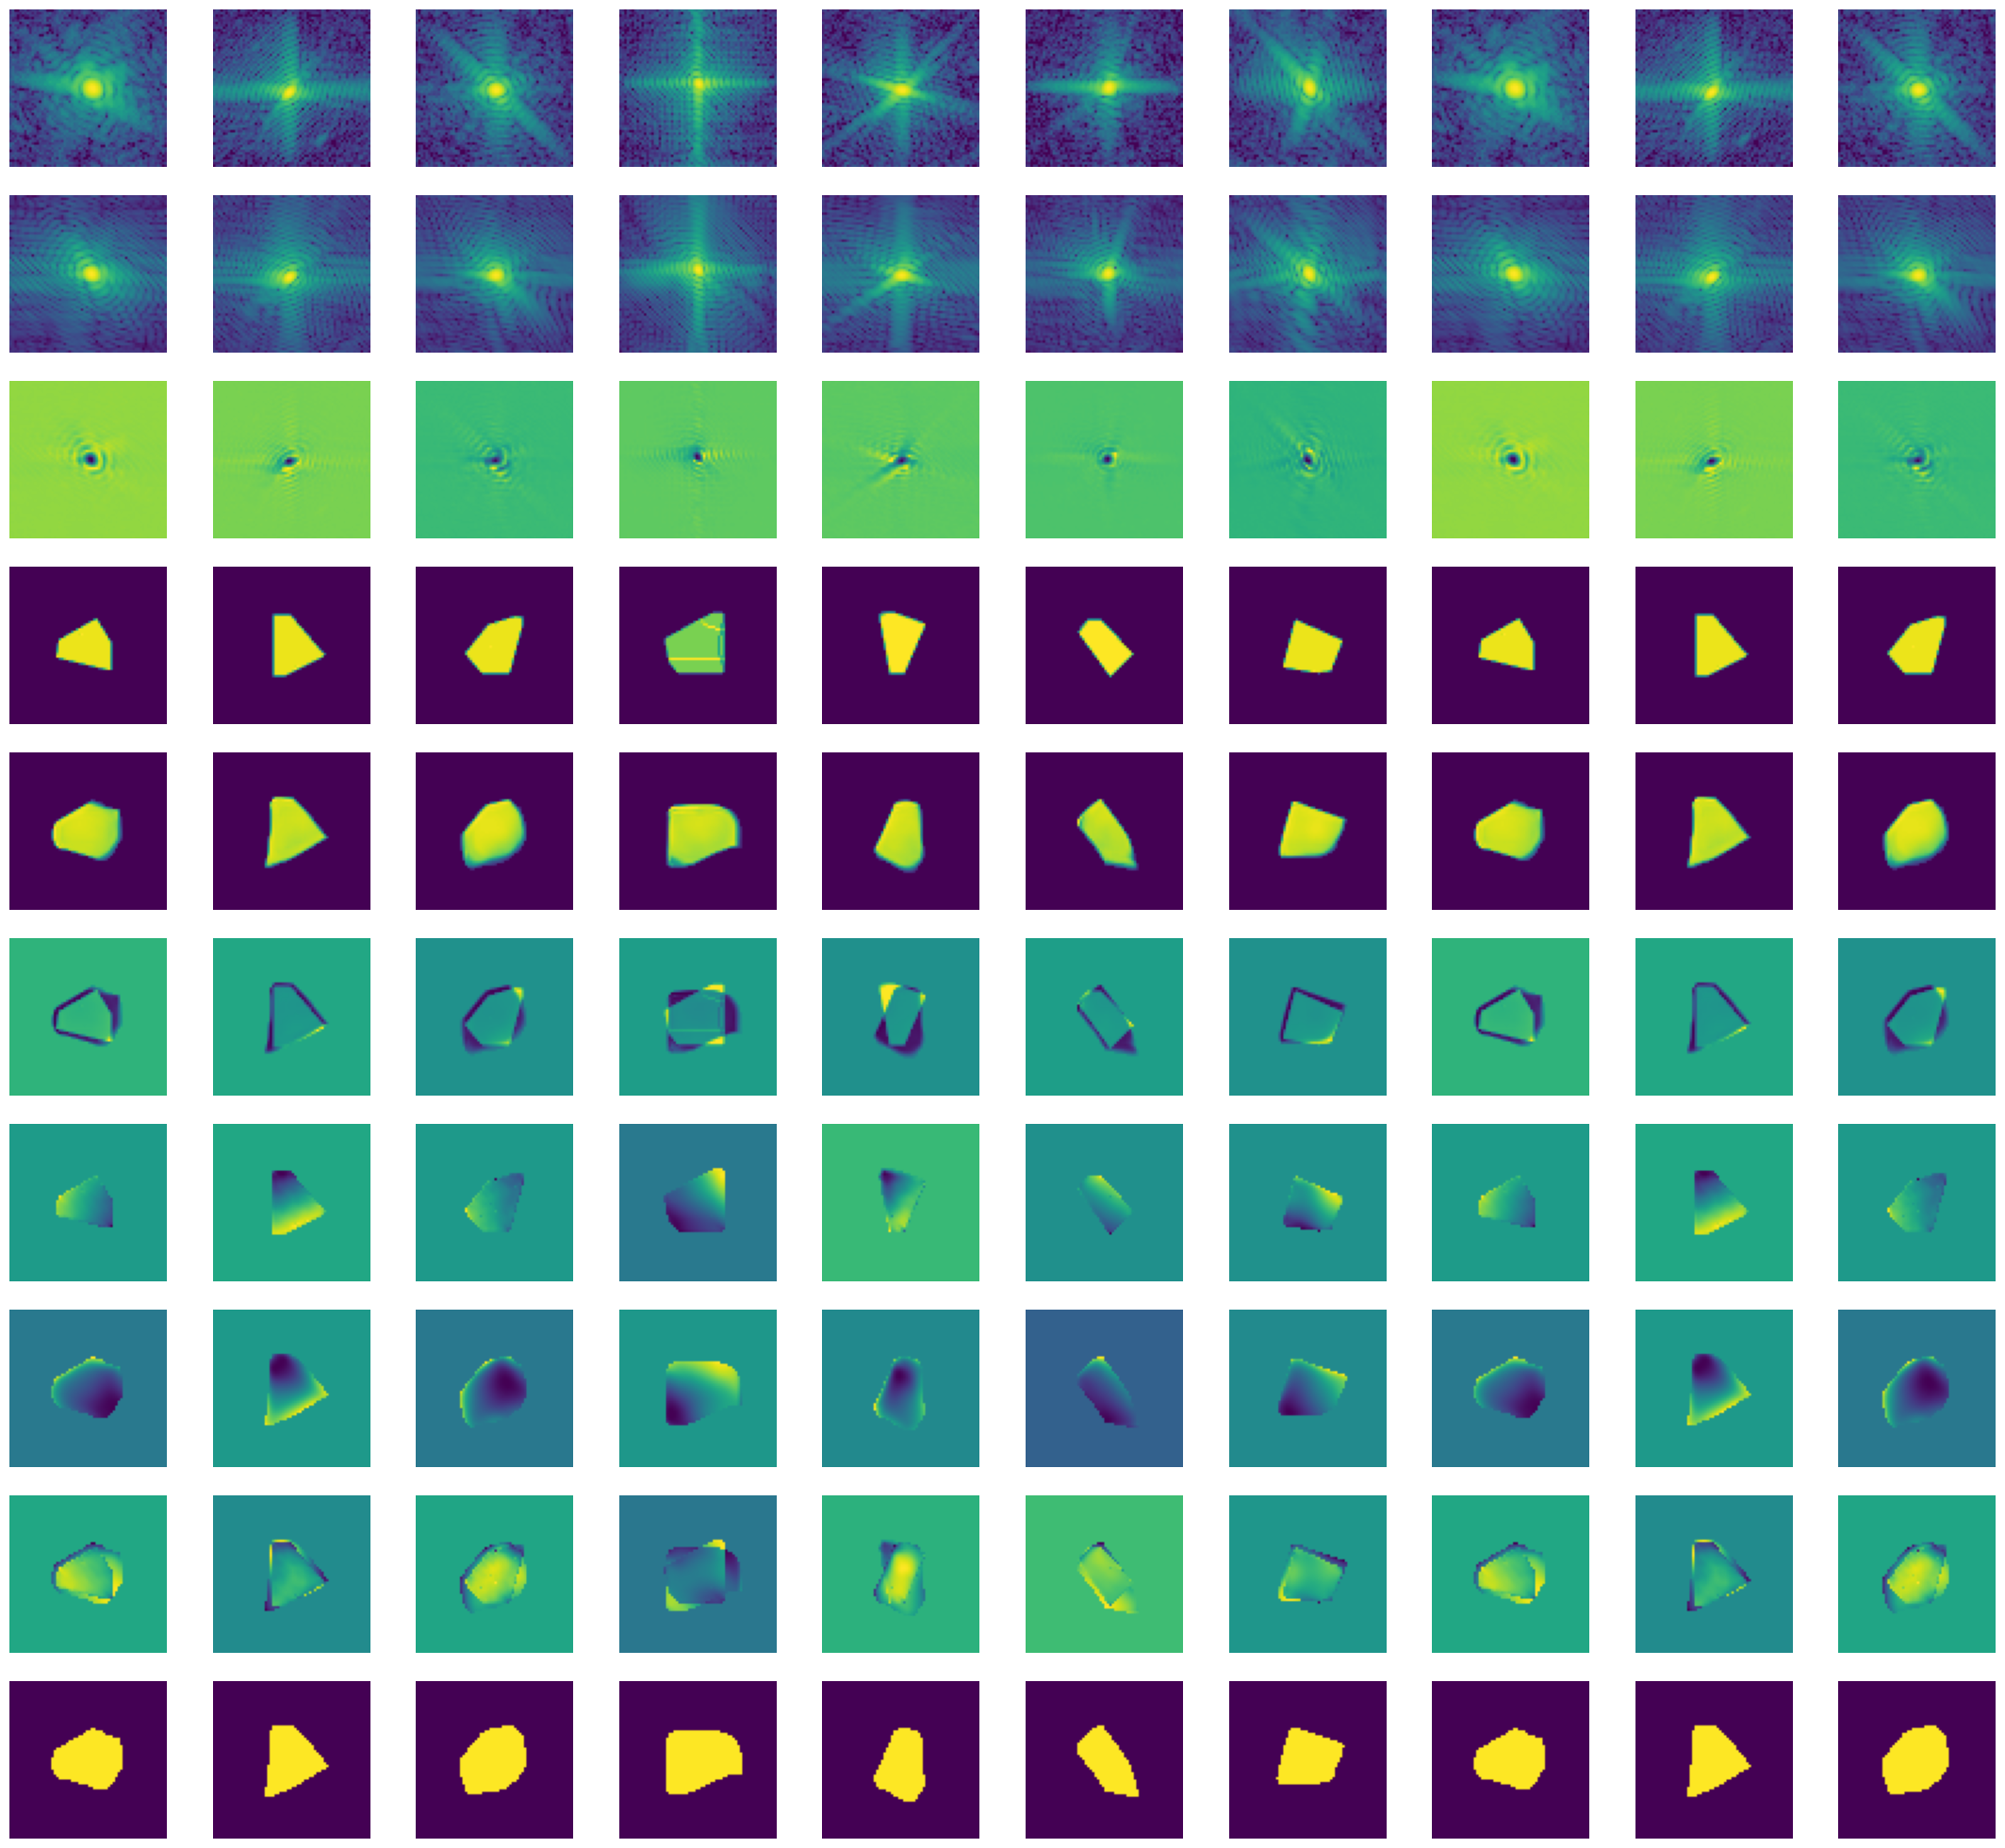

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.ndimage import center_of_mass
from skimage.restoration import unwrap_phase as skimage_unwrap

# ==========================================
# 1. 移植 TF 脚本中的工具函数 (完全复刻)
# ==========================================

h, w, t = 64, 64, 64  # 定义尺寸

def com(data):
    """计算质心 (Center of Mass)"""
    # 这里的 data 应该是 (H, W, T)
    # scipy 的 center_of_mass 返回 (z, y, x)
    return center_of_mass(data)

def shift_array(data, shift_deltas):
    """
    对应 TF 脚本里的 shift(..., mode='wrap')
    使用 np.roll 实现循环移位
    """
    # np.roll 的 shift 参数顺序对应 axis
    result = np.roll(data, shift=shift_deltas[0], axis=0)
    result = np.roll(result, shift=shift_deltas[1], axis=1)
    result = np.roll(result, shift=shift_deltas[2], axis=2)
    return result

def shift_com(amp, phi):
    """根据振幅的质心，将物体移动到图像中心"""
    coms = com(amp)
    if (np.isnan(coms[0]) or np.isnan(coms[1])):
        return amp, phi
        
    # 计算位移量 (Target Center - Current Center)
    # TF代码: h/2 - coms[0]
    deltas = (int(round(h / 2 - coms[0])), 
              int(round(w / 2 - coms[1])),
              int(round(t / 2 - coms[2])))
    
    amp_shift = shift_array(amp, deltas)
    phi_shift = shift_array(phi, deltas)
    return amp_shift, phi_shift

def shift_sup(support):
    """对 Support Mask 进行同样的移位"""
    coms = com(support)
    if (np.isnan(coms[0]) or np.isnan(coms[1])):
        return support
        
    deltas = (int(round(h / 2 - coms[0])), 
              int(round(w / 2 - coms[1])),
              int(round(t / 2 - coms[2])))
    
    support = shift_array(support, deltas)
    return support

def post_process(amp, phi, th=0.1, uw=0, flag=0):
    """
    完全复刻 TF 的后处理逻辑
    """
    amp = amp.reshape(h, w, t)
    phi = phi.reshape(h, w, t)

    # 1. 相位解缠
    if uw == 1:
        # TF 代码用的是 unwrap_phase，这里用 skimage 实现
        phi = skimage_unwrap(phi)

    # 2. 初始 Mask 过滤
    mask = np.where(amp > th, 1, 0)
    amp_out = mask * amp
    phi_out = mask * phi

    # 3. 相位均值归一化 (仅针对有值区域)
    if np.any(amp_out > th):
        mean_phi = np.mean(phi_out[amp_out > th])
        phi_out = phi_out - mean_phi
    
    # 4. 质心对齐 (这是最关键的一步！)
    amp_out, phi_out = shift_com(amp_out, phi_out)

    # 5. 二次 Mask 过滤 (移位后再次过滤)
    mask = np.where(amp_out > th, 1, 0)
    amp_out = mask * amp_out
    phi_out = mask * phi_out

    if flag == 1:
        phi_out = np.where(mask == 0, np.nan, phi_out)

    return amp_out, phi_out

# ==========================================
# 2. PyTorch 推理与绘图 (模仿 TF 的布局)
# ==========================================

model.eval()
index = 32  # 切片位置 (和 TF 保持一致)
n = 10      # 画 10 张图
f, ax = plt.subplots(10, n, figsize=(22, 20))

# 辅助函数：去 batch，转 numpy
def to_numpy(tensor):
    return tensor.detach().cpu().numpy()[0, ...]

# 我们用一个迭代器来模拟 TF 的随机抽取
data_iter = iter(test_loader)

  

with torch.no_grad():
    for i in range(n):
        try:
            # 获取一个 batch 的数据
            ft_images, amps, phs = next(data_iter)
        except StopIteration:
            data_iter = iter(test_loader)
            ft_images, amps, phs = next(data_iter)
            
        ft_images = ft_images.to(device)
        

        psi, obj, amp, ph, support = model(ft_images)
        
        # -------------------------------------------------
        # 计算并输出损失值 (对应 TF Raw Model Output 部分)
        # -------------------------------------------------
        
        # 1. 准备数据
        # 对应 TF 中的 raw_output_single = preds_intens[j].reshape(...)
        # 我们取当前 Batch 中的第一个样本进行评估
        Y_pred_raw = psi[0:1].float() 
        Y_true_raw = ft_images[0:1].float()

        # 2. 尝试添加 fftshift (对应 TF 中的修正 2)
        # 如果模型内部输出的是未位移的频谱，而输入是中心位移过的，则需要启用
        # Y_pred_raw = torch.fft.fftshift(Y_pred_raw, dim=(-3, -2, -1))

        # 3. 能量对齐 (Scale Alignment)
        # 确保预测值与真值在同一量级，防止 MSE 爆炸
        scale_raw = torch.sum(Y_true_raw) / (torch.sum(Y_pred_raw) + 1e-10)
        Y_pred_raw_scaled = Y_pred_raw * scale_raw

        # 4. 调用损失函数计算 (使用之前定义的 PyTorch 版本函数)
        l_paper = loss_paper(Y_true_raw, Y_pred_raw_scaled)
        l_log = loss_log(Y_true_raw, Y_pred_raw_scaled)
        l_sq = loss_sq(Y_true_raw, Y_pred_raw_scaled)
        l_mae = loss_mae(Y_true_raw, Y_pred_raw_scaled)
        l_pcc = loss_pcc(Y_true_raw, Y_pred_raw_scaled)
        l_comb = loss_comb(Y_true_raw, Y_pred_raw_scaled)

        # 5. 输出结果
        print(f"Sample {i} --- Raw Model Output (Internal Layer) Loss ---")
        print(f"  Loss Paper: {l_paper.item():.6f}")
        print(f"  Loss Log:   {l_log.item():.6f}")
        print(f"  Loss PCC:   {l_pcc.item():.6f} (Target: < 0.2)")
        print(f"  Real PCC:   {1.0 - l_pcc.item():.6f} (Target: > 0.8)")
        print(f"  Loss Comb:  {l_comb.item():.6f} (Target: Small Number)")
        print("-" * 30)
        
        # 取 Batch 中的第一个样本 (对应 TF 里的 j)
        X_test = to_numpy(ft_images)     # GT Farfield
        Y_I_test = to_numpy(amps)        # GT Amp
        Y_phi_test = to_numpy(phs)       # GT Phase
        
        preds_intens = to_numpy(psi)     # Pred Farfield
        preds_amp = to_numpy(amp)        # Pred Amp (原始)
        preds_phi = to_numpy(ph)         # Pred Phase (原始)
        preds_support = to_numpy(support)# Pred Support
        
        # -------------------------------------------------
        # 🚀 关键：应用 Post Process (和 TF 完全一致)
        # -------------------------------------------------
        
        # 处理 GT (Ground Truth)
        Y_I_test_proc, Y_phi_test_proc = post_process(
            Y_I_test, Y_phi_test, th=0.1, uw=1, flag=0
        )
        
        # 处理 Pred (Prediction)
        Y_I_pred_proc, Y_phi_pred_proc = post_process(
            preds_amp, preds_phi, th=0.1, uw=1, flag=0
        )
        
        # 处理 Support
        support_proc = preds_support.reshape(h, w, t)
        support_proc = shift_sup(support_proc)
        
        # 生成 Mask 用于显示
        mask_disp = np.where(Y_I_pred_proc[:, :, index].reshape(h, w) > 0.1, 1, 0)

        # -------------------------------------------------
        # 绘图 (完全复刻 TF 代码的 layout)
        # -------------------------------------------------
        
        # 1. Input FT Intensity
        im = ax[0, i].imshow(np.log10(X_test[:, :, index].reshape(h, w) + 1))
        ax[0, i].axis('off')
        
        # 2. Predicted FT Intensity
        im = ax[1, i].imshow(np.log10(preds_intens[:, :, index].reshape(h, w) + 1))
        ax[1, i].axis('off')
        
        # 3. Diff FT
        im = ax[2, i].imshow(X_test[:, :, index].reshape(h, w) - preds_intens[:, :, index].reshape(h, w))
        ax[2, i].axis('off')
        
        # 4. Original Amp (Processed)
        im = ax[3, i].imshow(Y_I_test_proc[:, :, index].reshape(h, w))
        ax[3, i].axis('off')
        
        # 5. Predicted Amp (Processed)
        im = ax[4, i].imshow(Y_I_pred_proc[:, :, index].reshape(h, w))
        ax[4, i].axis('off')
        
        # 6. Diff Amp
        im = ax[5, i].imshow(Y_I_test_proc[:, :, index].reshape(h, w) - Y_I_pred_proc[:, :, index].reshape(h, w))
        ax[5, i].axis('off')
        
        # 7. Original Phase (Processed)
        im = ax[6, i].imshow(Y_phi_test_proc[:, :, index].reshape(h, w))
        ax[6, i].axis('off')
        
        # 8. Predicted Phase (Processed + Masked)
        im = ax[7, i].imshow(mask_disp * Y_phi_pred_proc[:, :, index].reshape(h, w))
        ax[7, i].axis('off')
        
        # 9. Diff Phase
        im = ax[8, i].imshow(Y_phi_test_proc[:, :, index].reshape(h, w) - mask_disp * Y_phi_pred_proc[:, :, index].reshape(h, w))
        ax[8, i].axis('off')
        
        # 10. Support
        im = ax[9, i].imshow(support_proc[:, :, index].reshape(h, w))
        ax[9, i].axis('off')

plt.tight_layout()
plt.savefig('pytorch_result_fixed.png', dpi=300)
plt.show()

In [17]:
model.eval() #imp when have dropout etc
ft_results=[]
complex_results=[]
amp_preds = []
ph_preds  = []
supports = []

ft_test_array = []
amp_test_array = []
ph_test_array = []


for i, (ft_images,amps,phs) in enumerate(test_loader):
    ft_images = ft_images.to(device)
    y, complex_x, amp, ph, support = model(ft_images)
    #amp, ph, support = model(ft_images)
    for j in range(amp.shape[0]):
        #prediction
        ft_results.append([y[j].detach().to("cpu").numpy()])
        complex_results.append([complex_x[j].detach().to("cpu").numpy()])
        amp_preds.append(amp[j].detach().to("cpu").numpy())
        ph_preds.append(ph[j].detach().to("cpu").numpy())
        supports.append(support[j].detach().to("cpu").numpy())
        
        #ground truth
        ft_test_array.append([ft_images[j].detach().to("cpu").numpy()])
        amp_test_array.append([amps[j].detach().to("cpu").numpy()])
        ph_test_array.append([phs[j].detach().to("cpu").numpy()])
        

In [18]:
ft_results = np.array(ft_results).squeeze()
complex_results = np.array(complex_results).squeeze()
amp_preds = np.array(amp_preds).squeeze()
ph_preds = np.array(ph_preds).squeeze()
supports = np.array(supports).squeeze()

print(ft_results.shape, ft_results.dtype)

ft_test_array = np.array(ft_test_array).squeeze()
amp_test_array = np.array(amp_test_array).squeeze()
ph_test_array = np.array(ph_test_array).squeeze()

print(ft_test_array.shape, ft_test_array.dtype)

(100, 64, 64, 64) float32
(100, 64, 64, 64) float32


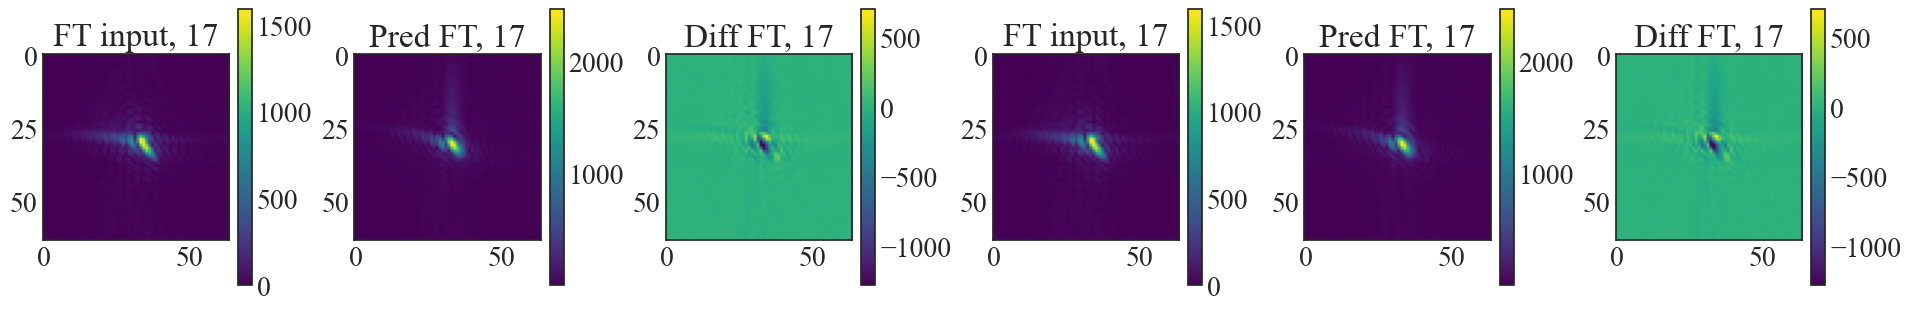

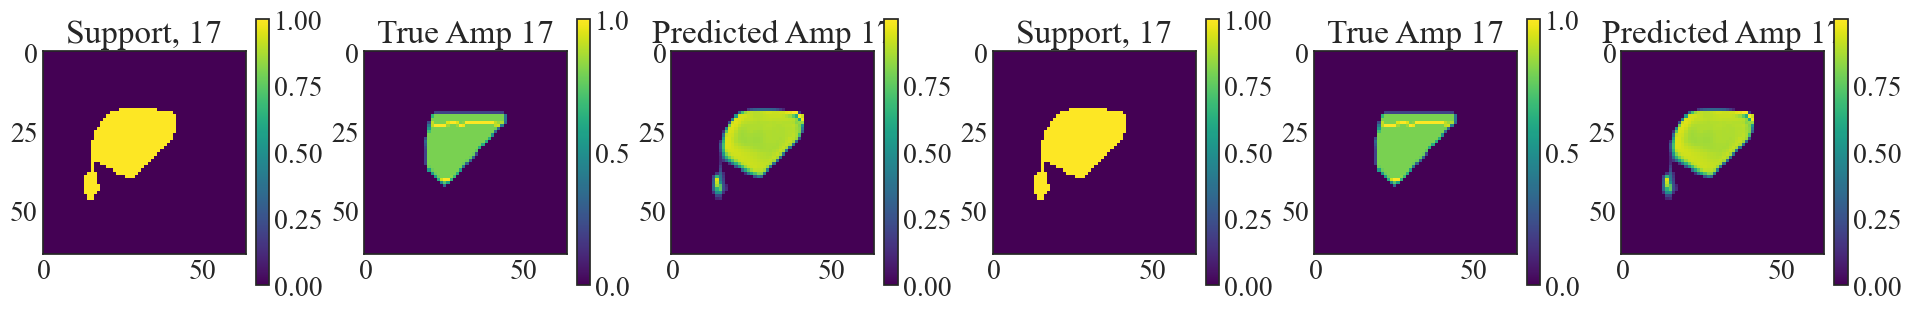

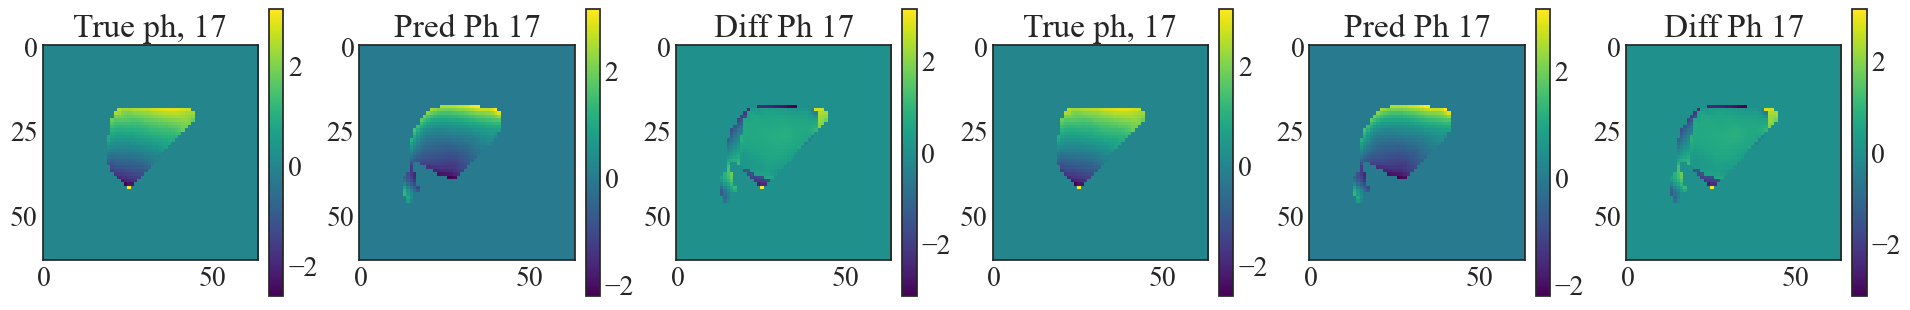

In [19]:
# Test images
to_plot = np.random.randint(100, size=2)
# to_plot = [20,50]

plots = {0:[], 1:[], 2:[]}
titles = {0:[], 1:[], 2:[]}
for i in to_plot:
    plots[0] += [ft_test_array[i],ft_results[i],ft_test_array[i]-ft_results[i]]
    titles[0] += [f"FT input, {i}", f"Pred FT, {i}", f"Diff FT, {i}"]
    
    plots[1] += [supports[i],amp_test_array[i],amp_preds[i]]
    titles[1] += [f"Support, {i}", f"True Amp {i}", f"Predicted Amp {i}"]
    
    tmp = ph_preds[i]*supports[i]
    plots[2] += [ph_test_array[i],tmp,ph_test_array[i]-tmp]
    titles[2] += [f"True ph, {i}", f"Pred Ph {i}", f"Diff Ph {i}"]

for j in range(3):
    plot6(plots[j], titles[j])